# W9-1 아래는 지난주에 진행했던 내용 예시 코드

**오늘 할 일**
1. 저번 주 Logistic Regression 흐름을 다시 한 번 따라가 보기
2. `SelectKBest`로 descriptor(=feature) **몇 개**를 쓸지 정하기
3. 같은 개수로 **MLP**, **SVM**도 학습시켜서 성능 비교

> 📝 **descriptor = feature** — 분자 구조를 숫자로 바꾼 값. 동일한 의미.

**데이터**: `skin_irritation_2Ddesc.csv` (저번 시간에 만든 파일)

**구성**
- Part A — 저번 주 코드 복습 (셀 그대로 실행)
- Part B — 이번 주 실습 (✏️ 표시 셀은 직접 채워 넣기)


---
# Part A. 저번 주 복습

셀을 하나씩 `Shift+Enter`로 실행하면서 주석 읽어 봐.


## A-1. 데이터 불러오기

`pandas.read_csv`로 파일 읽고 `df`에 담기.
- `df.shape` → (행, 열)
- `df.head()` → 위 5줄 미리보기

✅ **예상**: `(39, 220)` — 화합물 39개, 열 220개.


In [1]:
import pandas as pd

df = pd.read_csv('skin_irritation_2Ddesc.csv')
print('shape:', df.shape)
df.head()


shape: (39, 220)


,Chemical_Name,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Heptanal,CCCCCCC=O,1,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,...,0,0,0,0,0,0,0,0,4,0
1,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,...,1,0,0,0,0,0,0,0,0,0
2,Heptyl butyrate,CCCCCCCOC(=O)CCC,0,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,...,0,0,0,0,0,0,0,0,4,0
3,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,...,0,0,0,0,0,0,0,0,0,0
4,Methyl caproate,CCCCCC(=O)OC,0,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,...,0,0,0,0,0,0,0,0,2,0


## A-2. X / y 나누고 descriptor 정리

- `y` = `label` 열 (피부 자극: 0/1)
- `X` = 나머지 숫자 descriptor

버릴 거 두 가지:
1. **NaN 있는 열** — 일부 descriptor는 특정 분자에서 계산이 실패해 `NaN`이 돼. 👉 저번 주 마지막에 `clf.fit(X, y)`가 터진 이유가 바로 이거야.
2. **표준편차 0.01 미만 열** — 거의 다 같은 값이면 구분력이 없으니 빼.

✅ **예상**: NaN 제거 `(39, 209)` → std 필터 `(39, 144)`


In [2]:
y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

X = X.dropna(axis=1)                 # NaN 열 제거
print('NaN 제거:', X.shape)

X = X.loc[:, X.std() >= 0.01]        # 저분산 제거
print('std 필터:', X.shape)


NaN 제거: (39, 209)
std 필터: (39, 144)


## A-3. 전체 descriptor로 Logistic Regression

일단 다 넣고 돌려 봐.
- `clf.fit(X, y)` : 학습
- `clf.score(X, y)` : 학습 데이터 정확도 — 1.0에 가까워도 좋아하면 안 돼(**overfitting** 의심).
- `cross_val_score(..., cv=5)` : 5등분해서 돌아가며 검증. 진짜 성능은 이쪽.
- 함수 설명: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
- cross validation 설명: https://scikit-learn.org/stable/modules/cross_validation.html

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

'''
descriptor 단위가 달라서 표준화 (사실 2D descriptor 사용할 때는 normalization이 필수!)
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

standardscaler는 descriptor 값을 평균과 표준편차로 표준화시키는 방법. (나는 고등학교 때 수학 시간에 확률과 통계 시간에 배웠던 것 같은데...)

또 다른 표준화 방식은 descriptor의 최대, 최소 값을 이용하는 것.
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

표준화 하는 이유
1) descriptor 범위가 너무 달라서 해석이 어려움 (MW: 100~700, logP: -2~8)  -> y(0~1)=a*x1(MW)+b*x2(logP)+c
2) ML 모델 학습이 어려움 (descriptor 값의 스케일이 너무 다르면, loss 함수가 복잡해져서 학습이 느려짐)
'''

# descriptor값 표준화
X_scaled = StandardScaler().fit_transform(X)   
print ('변경 전')
print (X_scaled)


변경 전
[[ 0.23289658  0.23289658  1.30007403 ... -0.23249528 -0.16222142
   0.25736848]
 [ 0.42199334  0.42199334  1.24766006 ... -0.23249528  6.164414
  -0.79919684]
 [ 0.733452    0.733452   -1.02500828 ... -0.23249528 -0.16222142
   0.25736848]
 ...
 [ 0.91886678  0.91886678 -1.07844588 ... -0.23249528 -0.16222142
   2.37049912]
 [-0.35689835 -0.35689835  0.04019605 ... -0.23249528 -0.16222142
   0.52150981]
 [-0.41385079 -0.41385079  0.02019799 ... -0.23249528 -0.16222142
  -0.00677285]]


In [4]:
print ('변경 후')
#pandas dataframe을 모두 numpy array로 바꿨음.
#feature selection이 나중에 어려움... (column 명으로 선택하고 싶은데)
scaler = StandardScaler()

#변경된 코드: normalization 이후에 dataframe으로 다시 변환
X_scaled = pd.DataFrame(
    scaler.fit_transform(X), 
    columns=X.columns, 
    index=X.index
)

X_scaled


변경 후


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_ether,fr_halogen,fr_ketone,fr_ketone_Topliss,fr_methoxy,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_sulfide,fr_unbrch_alkane
0,0.232897,0.232897,1.300074,1.058002,-0.913297,-0.599121,-0.976642,-0.994104,-0.975506,-0.858962,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,0.257368
1,0.421993,0.421993,1.247660,1.040576,-0.241314,-0.555112,-0.381719,-0.247747,-0.381905,-0.701687,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,6.164414,-0.799197
2,0.733452,0.733452,-1.025008,0.189751,-0.634052,-0.379076,0.151364,0.090314,0.152333,0.320598,...,1.274755,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,0.257368
3,1.056632,1.056632,0.047698,-0.408201,0.598477,0.455379,2.014864,2.022042,2.015494,2.050620,...,1.274755,-0.219971,-0.162221,-0.162221,2.159002,3.464102,-0.232495,-0.232495,-0.162221,-0.799197
4,0.538220,0.538220,-0.858803,0.134494,-0.646345,-0.602613,-0.726361,-0.723199,-0.725155,-0.623050,...,1.274755,-0.219971,-0.162221,-0.162221,2.159002,-0.288675,-0.232495,-0.232495,-0.162221,-0.270914
5,-3.046498,-3.046498,0.370031,0.748798,1.507939,0.301398,0.746630,0.768771,0.747021,0.713785,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,-0.799197
6,1.060924,1.060924,-0.956657,-0.333057,2.578344,-0.408662,0.807640,0.971354,0.808410,0.635148,...,1.274755,-0.219971,-0.162221,-0.162221,-0.317500,3.464102,4.301163,4.301163,-0.162221,-0.799197
7,0.384508,0.384508,-1.168258,-4.669289,-2.303128,-0.071712,1.748409,1.767764,1.748442,1.342884,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,1.578075
8,-1.699967,-1.699967,1.455488,1.109671,-0.448737,-0.630555,-0.080629,0.078156,-0.101419,-1.252148,...,-0.637377,5.499267,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,-0.535056
9,0.318148,0.318148,-0.071222,-0.501083,0.584913,-0.518787,-0.726361,-0.723199,-0.725155,-0.623050,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,-0.006773


In [5]:
clf = LogisticRegression(max_iter=5000)
clf.fit(X_scaled, y)
print('train :', clf.score(X_scaled, y))
print('CV5   :', cross_val_score(clf, X_scaled, y, cv=5).mean().round(3))

train : 0.9743589743589743
CV5   : 0.789


---
# Part B. 이번 주 실습

✏️ 셀 3개를 직접 채워. 바로 위 Part A를 참고하면 충분해.

1. `SelectKBest` + Logistic Regression으로 **최적 K** 찾기
2. 같은 K로 **MLP** — 로지스틱보다 나은가?
3. 같은 K로 **SVM** — `C`, `kernel` 바꿔 보기


## B-0. SelectKBest 개념

> 📌 **성능 숫자 해석 팁**: 샘플이 39개뿐이니까 5-fold CV는 fold당 8개 정도만 들어가. **±0.1 변동은 정상**이야. 미세한 차이로 모델 좋고 나쁨을 단정하지 마.

데이터는 39개, descriptor는 144개. 입력이 너무 많으면 노이즈에 묻혀서 패턴을 못 잡아. `SelectKBest`는 **y와 관련 높은 상위 K개**만 골라.

- 📖 <https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html>

> ⚠️ `SelectKBest(f_classif, ...)`는 스케일 영향을 안 받아서 원본 `X`에 써도 돼. 대신 **모델 학습 직전엔 반드시 `StandardScaler`**. 순서: `SelectKBest` → `StandardScaler` → 모델.

**사용법** (3줄):
```python
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=10)
X_new = selector.fit_transform(X, y)
```

K=10으로 뽑히는 descriptor 이름 먼저 확인.


In [6]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)
print(list(X.columns[selector.get_support()]))


['MinAbsEStateIndex', 'BertzCT', 'Chi0', 'Chi1', 'PEOE_VSA7', 'SlogP_VSA6', 'HeavyAtomCount', 'MolMR', 'fr_C_O_noCOO', 'fr_ester']


## ✏️ 실습 1 — Logistic Regression 최적 K

K를 바꿔 가며 5-fold CV 정확도 비교. 제일 높은 K가 **`best_k`**.

**힌트**
1. `for k in k_candidates:` 루프
2. 루프 안에서 `SelectKBest(f_classif, k)` → `StandardScaler` → `LogisticRegression(max_iter=5000)` 의 CV 점수
3. 가장 높은 k를 `best_k`에 저장 (다음 실습에서 재사용)

✅ **경향**: 너무 적으면 정보 부족, 너무 많으면 노이즈.


In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

#scikit-learn 교차 검증 설명 자료
#https://scikit-learn.org/stable/modules/cross_validation.html

k_candidates = [5, 10, 15, 20, 25, 30, 40, 50]
best_k, best_score = None, -1

# TODO: 각 k에 대해 SelectKBest → StandardScaler → LogReg CV5
#       k, acc 출력 + best_k/best_score 업데이트
#       예시 출력: 'k=10: 0.793'
for k in k_candidates:
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_scaled, y) #Normalization 진행한 데이터로 해야함.
    selected_feature = X_scaled.columns[selector.get_support()]
    #print (selected_feature)
    X_selec = X_scaled[selected_feature]
    
    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_selec, y)
    print('k:',k,'/ train:', clf.score(X_selec, y), \
          '/ 5-foldCV:', cross_val_score(clf, X_selec, y, cv=5).mean().round(3))

k: 5 / train: 0.717948717948718 / 5-foldCV: 0.668
k: 10 / train: 0.8717948717948718 / 5-foldCV: 0.793
k: 15 / train: 0.8974358974358975 / 5-foldCV: 0.793
k: 20 / train: 0.8717948717948718 / 5-foldCV: 0.793
k: 25 / train: 0.8974358974358975 / 5-foldCV: 0.743
k: 30 / train: 0.8974358974358975 / 5-foldCV: 0.743
k: 40 / train: 0.8974358974358975 / 5-foldCV: 0.664
k: 50 / train: 0.9230769230769231 / 5-foldCV: 0.661


## ✏️ 실습 2 — 같은 K로 MLP

실습 1의 `best_k` 그대로. 모델만 `LogisticRegression` → `MLPClassifier`.

**힌트**
- `from sklearn.neural_network import MLPClassifier`
- `MLPClassifier(random_state=0, max_iter=2000)`
- hidden layer 1개, hidden node 개수는 k와 동일하게 설정
- 데이터가 적으면 MLP가 로지스틱보다 **떨어질 수도** 있어. 그것도 배움이야.


In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# TODO: best_k로 SelectKBest → StandardScaler → MLPClassifier(random_state=0, max_iter=2000)
#       CV5 점수 출력 + 실습 1 결과와 한 줄 비교
hidden_nodes = [10,5,3]
activation = ['logistic','tanh','relu']
for h in hidden_nodes:
    print ('hidden nodes:',h)
    for a in activation:
        ann = MLPClassifier(hidden_layer_sizes=(h,),activation=a, max_iter=5000)
        ann.fit(X_selec, y)
        print('activation function:',a, \
              '/ train:', ann.score(X_selec, y), \
              '/ 5-foldCV:', cross_val_score(ann, X_selec, y, cv=5).mean().round(3))

hidden nodes: 10
activation function: logistic / train: 1.0 / 5-foldCV: 0.743
activation function: tanh / train: 1.0 / 5-foldCV: 0.714
activation function: relu / train: 1.0 / 5-foldCV: 0.743
hidden nodes: 5
activation function: logistic / train: 0.9230769230769231 / 5-foldCV: 0.771
activation function: tanh / train: 1.0 / 5-foldCV: 0.743
activation function: relu / train: 0.9743589743589743 / 5-foldCV: 0.793
hidden nodes: 3
activation function: logistic / train: 0.9230769230769231 / 5-foldCV: 0.743
activation function: tanh / train: 1.0 / 5-foldCV: 0.714
activation function: relu / train: 0.9487179487179487 / 5-foldCV: 0.739


## B-3. SVM 개념

SVM은 **두 그룹 사이에 제일 넉넉한 경계선**을 찾아. 경계에 가까운 점(support vector)과의 거리(margin)를 최대로.

핵심 2개만 기억하면 돼.

| 이름 | 역할 | 크면 | 작으면 |
|------|------|------|--------|
| `C` | regularization의 역수 | 학습 데이터에 바짝 맞춤 → overfitting↑ | 경계 부드러움 → underfitting 가능 |
| `kernel` | 경계 모양 | `linear`: 직선 / `rbf`: 종 모양 곡선 / `poly`: 다항식 | — |

- 📖 SVC: <https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html>
- 📖 SVM 해설: <https://scikit-learn.org/stable/modules/svm.html>


## ✏️ 실습 3 — 같은 K로 SVM (`C` × `kernel`)

`best_k`로 descriptor 뽑고, `C`와 `kernel` 조합을 표처럼 찍어 봐.

**힌트**
- `from sklearn.svm import SVC`
- 이중 for: `for C in [0.1, 1, 10]: for kernel in ['linear', 'rbf', 'poly']:`
- RBF/poly는 스케일에 민감 → **`StandardScaler` 필수**
- 💡 `poly`는 경고 뜰 수 있는데 정상. 거슬리면 `import warnings; warnings.filterwarnings('ignore')`.


In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# TODO: best_k로 X_sel 만들고, C × kernel 조합 CV5 출력
#       예시 출력: 'C=0.1, kernel=linear : 0.775'
C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
kernel = ['linear','poly','rbf','sigmoid']

# for문을 이용해서 hyperparameter를 탐색하는 방식을 grid search라고 함.
for c in C:
    print ('C:',c)
    for kf in kernel:
        svm = SVC(C=c, kernel=kf)
        svm.fit(X_selec, y)
        print('kernel:', kf, \
              '/ train:', ann.score(X_selec, y), \
              '/ 5-foldCV:', cross_val_score(ann, X_selec, y, cv=5).mean().round(3))

C: 0.01
kernel: linear / train: 0.9487179487179487 / 5-foldCV: 0.714
kernel: poly / train: 0.9487179487179487 / 5-foldCV: 0.714
kernel: rbf / train: 0.9487179487179487 / 5-foldCV: 0.721
kernel: sigmoid / train: 0.9487179487179487 / 5-foldCV: 0.818
C: 0.03
kernel: linear / train: 0.9487179487179487 / 5-foldCV: 0.664
kernel: poly / train: 0.9487179487179487 / 5-foldCV: 0.721
kernel: rbf / train: 0.9487179487179487 / 5-foldCV: 0.636
kernel: sigmoid / train: 0.9487179487179487 / 5-foldCV: 0.768
C: 0.1
kernel: linear / train: 0.9487179487179487 / 5-foldCV: 0.739
kernel: poly / train: 0.9487179487179487 / 5-foldCV: 0.825
kernel: rbf / train: 0.9487179487179487 / 5-foldCV: 0.75
kernel: sigmoid / train: 0.9487179487179487 / 5-foldCV: 0.768
C: 0.3
kernel: linear / train: 0.9487179487179487 / 5-foldCV: 0.632
kernel: poly / train: 0.9487179487179487 / 5-foldCV: 0.636
kernel: rbf / train: 0.9487179487179487 / 5-foldCV: 0.686
kernel: sigmoid / train: 0.9487179487179487 / 5-foldCV: 0.793
C: 1
kernel

---
## 스스로 확인

세 실습을 다 채워 실행했으면, 아래 질문에 머릿속으로 답해 봐.

- (Q1) 최적 K는 몇? 왜? --> 10에서 가장 좋은 결과. 하지만 5에서 10으로 바뀌면서 정확도가 크게 달라지기 때문에 5~10 사이를 세밀하게 확인해보는 것도 필요.
- (Q2) 같은 K에서 MLP가 로지스틱보다 좋게 나올까? 이유는? 데이터 수가 적기 때문에 단순한 모델의 성능이 더 뛰어남. 단순한 모델일수록 과적합 (overfitting)가능성도 줄어들게 됨.
- (Q3) SVM에서 제일 좋은 `(C, kernel)` 조합은? (0.1, linear) 데이터가 적어서 더 단순한 커널이 성능이 더 좋게 나옴.


---
# w9-2. 결과 정리 + 시각화

`print()`로만 보면 실험이 늘어났을 때 눈으로 따라가기 너무 힘들어. 표로 모아 csv로 저장하고, 그래프로 한 번에 보면 비교가 훨씬 편해져.

이번 파트에서 할 일
1. 모든 실험 결과를 **DataFrame**으로 모으기
2. **csv 파일**로 저장 (엑셀로도 열림)
3. **막대 그래프**로 모델별 최고 점수 비교
4. **학습 곡선** — k(feature 개수)를 늘려가며 CV 정확도 변화 보기

> 📌 **시험 포인트**: 표 정리 + 그래프 그리기는 자주 묻는 부분이야. 코드 흐름을 손에 익혀 둬.

## C-1. 실험 결과를 표로 모으기

`print()`만 쓰면 출력이 흘러가서 다시 비교하기 어려워. 정석은 **list of dict** → `pandas.DataFrame`.
- 값을 저장하는 이유는 나중에 learning curve를 그리기 위함 (C-4 참고)

순서 (3줄)
1. 빈 리스트 `results = []`
2. 루프 안에서 `results.append({'model': ..., 'k': ..., 'cv': ...})`
3. 끝나면 `pd.DataFrame(results).to_csv('파일명.csv', index=False)`

> ⚠️ `SelectKBest` 후에도 **DataFrame을 유지**해야 나중에 컬럼 이름으로 feature를 선택할 수 있어. `X_scaled.columns[selector.get_support()]`로 컬럼명을 뽑고, `X_scaled[cols]`로 골라야 해.

In [26]:
import pandas as pd
import warnings
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')   # 파이썬에서 출력되는 경고 무시하는 방법

results = []
k_candidates = [4, 6, 8, 10, 12, 14]

# neural network hyperparameters
hidden_nodes = [10,5,3]
activation = ['logistic','tanh','relu']

C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
kernel = ['linear','poly','rbf','sigmoid']

for k in k_candidates:
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_scaled, y)
    cols = X_scaled.columns[selector.get_support()]
    X_sel = X_scaled[cols]                       # DataFrame 유지

    #logistic regression
    clf = LogisticRegression(max_iter=5000)
    train = clf.fit(X_sel, y).score(X_sel, y)
    cv = cross_val_score(clf, X_sel, y, cv=5).mean()
    results.append({'model': 'LogReg', 'k': k, 'param': '-',
                    'train': round(train, 3), 'cv': round(cv, 3)})

    #artificial neural network
    for h in hidden_nodes:
        for a in activation:
            ann = MLPClassifier(hidden_layer_sizes=(h,),activation=a, max_iter=5000)
            train = ann.fit(X_sel, y).score(X_sel, y)
            cv = cross_val_score(ann, X_sel, y, cv=5).mean()
            results.append({'model': 'ANN', 'k': k, 'param': f'{h, a}',
                            'train': round(train, 3), 'cv': round(cv, 3)})

    #support vector machine
    for c in C:
        for kf in kernel:
            svm = SVC(C=c, kernel=kf)
            train = svm.fit(X_sel, y).score(X_sel, y)
            cv = cross_val_score(svm, X_sel, y, cv=5).mean()
            results.append({'model': 'SVM', 'k': k, 'param': f'{c, kf}',
                            'train': round(train, 3), 'cv': round(cv, 3)})

results_df = pd.DataFrame(results)
results_df.to_csv('experiment_results.csv', index=False)
print('저장 완료: experiment_results.csv  /  전체 실험:', len(results_df), '개')
results_df.head()

저장 완료: experiment_results.csv  /  전체 실험: 368 개


,model,k,param,train,cv
0,LogReg,5,-,0.718,0.668
1,ANN,5,"(10, 'logistic')",0.744,0.696
2,ANN,5,"(10, 'tanh')",0.974,0.671
3,ANN,5,"(10, 'relu')",0.949,0.639
4,ANN,5,"(5, 'logistic')",0.769,0.696


## C-2. 베스트 결과 골라 보기

표가 만들어졌으니 정렬하고 모델별 1등만 뽑자.
- `sort_values('cv', ascending=False)` → CV 점수 높은 순
- `groupby('model').head(1)` → 모델당 최고 1줄

In [27]:
# 전체 Top 5
top5 = results_df.sort_values('cv', ascending=False).head(5)
print('=== Top 5 (전체) ===')
print(top5.to_string(index=False))

# 모델별 베스트 — sort → groupby → head(1) 패턴 (model 알파벳 순으로 정렬해 보기 편하게)
best_each = (results_df.sort_values('cv', ascending=False)
                       .groupby('model')
                       .head(1))
print()
print('=== 모델별 베스트 ===')
print(best_each.to_string(index=False))

best_each.to_csv('experiment_best.csv', index=False)
print()
print('저장 완료: experiment_best.csv')

=== Top 5 (전체) ===
model  k      param  train    cv
  SVM 15 (3, 'rbf')  0.897 0.846
  SVM 40 (3, 'rbf')  0.923 0.825
  SVM 10 (3, 'rbf')  0.872 0.821
  SVM 25 (3, 'rbf')  0.923 0.821
  SVM 30 (3, 'rbf')  0.923 0.821

=== 모델별 베스트 ===
 model  k           param  train    cv
   SVM 15      (3, 'rbf')  0.897 0.846
   ANN 15 (5, 'logistic')  1.000 0.818
LogReg 10               -  0.872 0.793

저장 완료: experiment_best.csv


## C-3. 그래프 1 — 모델별 최고 CV 점수 비교

수치만 보지 말고 **막대 그래프**로 한눈에 보자. 보고서나 발표 슬라이드에 그대로 쓸 수 있어.

> 💡 한글 폰트가 깨지면 그래프 글자가 □□□로 나올 수 있어. 그래서 제목·축 라벨은 영문으로 적었어.

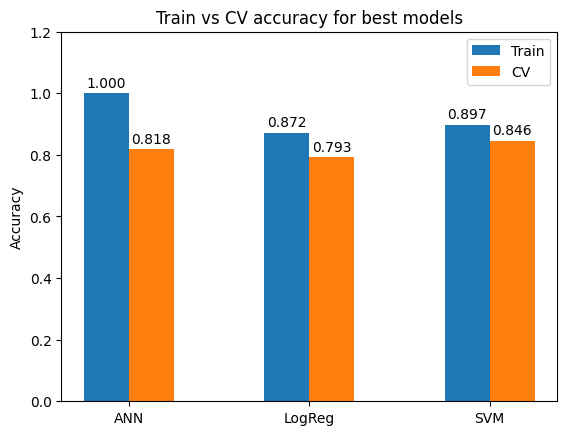

In [32]:
import matplotlib.pyplot as plt
import numpy as np

best_each = (results_df.sort_values('cv', ascending=False)
                       .groupby('model').head(1)
                       .sort_values('model'))

x = np.arange(len(best_each))
width = 0.25

plt.bar(x - width/2, best_each['train'], width, label='Train')
plt.bar(x + width/2, best_each['cv'], width, label='CV')

plt.xticks(x, best_each['model'])
plt.ylim(0, 1.2)
plt.ylabel('Accuracy')
plt.title('Train vs CV accuracy for best models')
plt.legend(loc=0)

# 막대 위에 점수 텍스트 표시
for i, v in enumerate(best_each['train'].values):
    plt.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center')

for i, v in enumerate(best_each['cv'].values):
    plt.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center')

plt.show()

## C-4. 그래프 2 — 학습 곡선 (k vs CV 정확도)

아래 코드는 logistic regression의 성능 변화를 나타낸 plot.
- 위에서 MLP와 SVM결과도 저장했다면, results_df에 결과가 같이 저장되어 있을테니, learning curve를 그려볼 것.

> 💡 너무 적으면 정보 부족(**underfitting**), 너무 많으면 노이즈(**overfitting**). 둘 사이 꼭짓점이 최적 k.

In [14]:
#결과 저장할 때 사용했던 모델 이름 확인.
results_df['model'].unique()

<ArrowStringArray>
['LogReg']
Length: 1, dtype: str

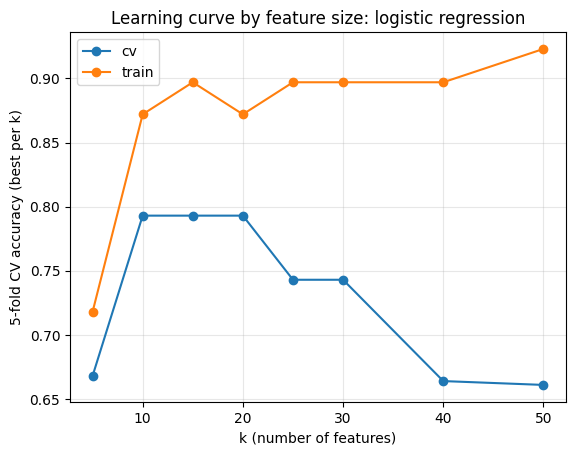

In [50]:
# 모델 × k 조합에서 최고 CV만 골라 곡선 데이터 만들기 (각 점 = 그 k에서의 최고 param)

df_lr = results_df[results_df['model']=='LogReg']

plt.plot(df_lr['k'], df_lr['cv'], marker='o', label='cv')
plt.plot(df_lr['k'], df_lr['train'], marker='o', label='train')


plt.xlabel('k (number of features)')
plt.ylabel('5-fold CV accuracy (best per k)')
plt.title('Learning curve by feature size: logistic regression')
plt.legend(loc=0)
plt.grid(alpha=0.3)
plt.show()

In [48]:
df_ann = results_df[results_df['model']=='ANN']
df_ann

,model,k,param,train,cv
1,ANN,5,"(10, 'logistic')",0.744,0.696
2,ANN,5,"(10, 'tanh')",0.974,0.671
3,ANN,5,"(10, 'relu')",0.949,0.639
4,ANN,5,"(5, 'logistic')",0.769,0.696
5,ANN,5,"(5, 'tanh')",0.795,0.618
...,...,...,...,...,...
327,ANN,50,"(5, 'tanh')",1.000,0.768
328,ANN,50,"(5, 'relu')",0.974,0.768
329,ANN,50,"(3, 'logistic')",0.949,0.768
330,ANN,50,"(3, 'tanh')",0.923,0.793


In [49]:
df_ann_k = df_ann.sort_values('cv', ascending=False).groupby('k').head(1).sort_values('k')
df_ann_k

,model,k,param,train,cv
6,ANN,5,"(5, 'relu')",0.872,0.796
49,ANN,10,"(10, 'relu')",0.923,0.818
96,ANN,15,"(5, 'logistic')",1.000,0.818
144,ANN,20,"(5, 'relu')",1.000,0.793
187,ANN,25,"(10, 'relu')",1.000,0.796
237,ANN,30,"(3, 'logistic')",0.974,0.793
285,ANN,40,"(3, 'relu')",0.949,0.771
330,ANN,50,"(3, 'tanh')",0.923,0.793


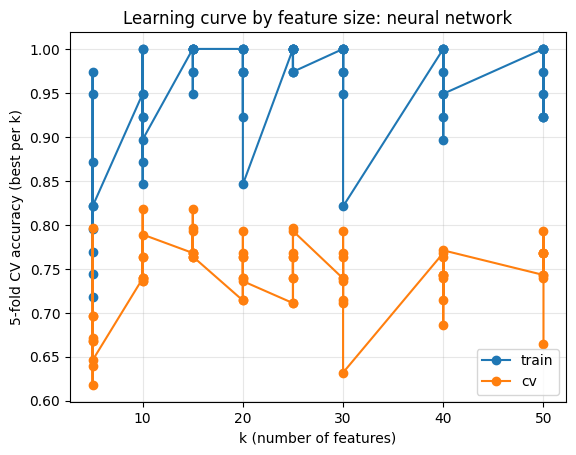

In [43]:
# logistic regression에서 진행했던 내용을 참고해서, MLP, SVM의 learning curve 그려보기
# 모델 × k 조합에서 최고 CV만 골라 곡선 데이터 만들기 (각 점 = 그 k에서의 최고 param)

#잘못 그린 버전
plt.plot(df_ann['k'], df_ann['train'], marker='o', label='train')
plt.plot(df_ann['k'], df_ann['cv'], marker='o', label='cv')

plt.xlabel('k (number of features)')
plt.ylabel('5-fold CV accuracy (best per k)')
plt.title('Learning curve by feature size: neural network')
plt.legend(loc=0)
plt.grid(alpha=0.3)
plt.show()

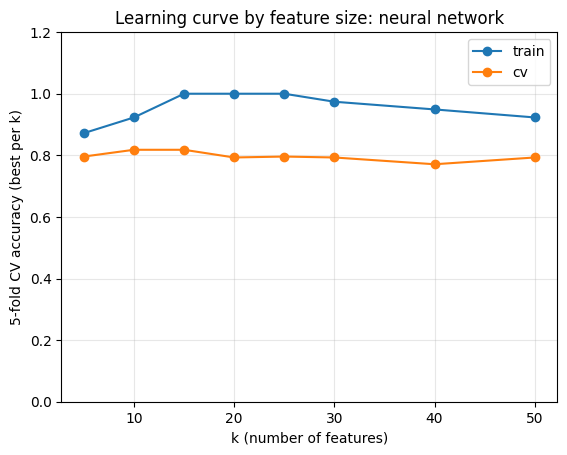

In [53]:
#의도했던 그래프
plt.plot(df_ann_k['k'], df_ann_k['train'], marker='o', label='train')
plt.plot(df_ann_k['k'], df_ann_k['cv'], marker='o', label='cv')

plt.xlabel('k (number of features)')
plt.ylabel('5-fold CV accuracy (best per k)')
plt.title('Learning curve by feature size: neural network')
plt.ylim(0,1.2)
plt.legend(loc=0)
plt.grid(alpha=0.3)
plt.show()

In [46]:
df_svm = results_df[results_df['model']=='SVM']
df_svm_k = df_svm.sort_values('cv', ascending=False).groupby('k').head(1).sort_values('k')
df_svm_k

,model,k,param,train,cv
33,SVM,5,"(3, 'sigmoid')",0.769,0.800
78,SVM,10,"(3, 'rbf')",0.872,0.821
124,SVM,15,"(3, 'rbf')",0.897,0.846
170,SVM,20,"(3, 'rbf')",0.923,0.796
216,SVM,25,"(3, 'rbf')",0.923,0.821
262,SVM,30,"(3, 'rbf')",0.923,0.821
308,SVM,40,"(3, 'rbf')",0.923,0.825
354,SVM,50,"(3, 'rbf')",0.923,0.800


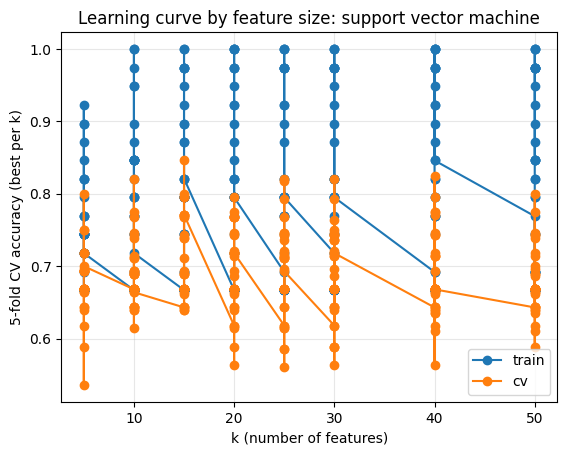

In [36]:
#잘못 그린 그래프
plt.plot(df_svm['k'], df_svm['train'], marker='o', label='train')
plt.plot(df_svm['k'], df_svm['cv'], marker='o', label='cv')

plt.xlabel('k (number of features)')
plt.ylabel('5-fold CV accuracy (best per k)')
plt.title('Learning curve by feature size: support vector machine')
plt.legend(loc=0)
plt.grid(alpha=0.3)
plt.show()

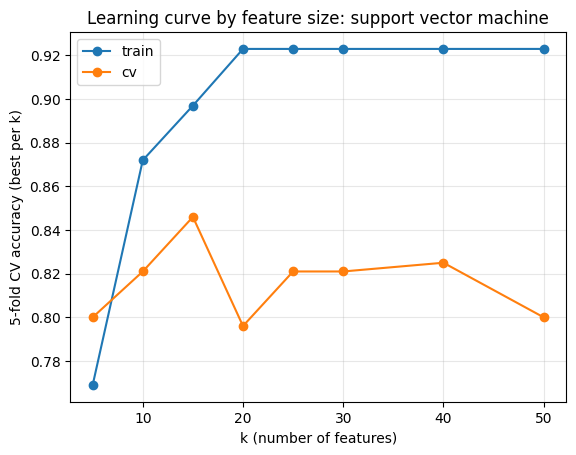

In [47]:
#의도했던 그래프
plt.plot(df_svm_k['k'], df_svm_k['train'], marker='o', label='train')
plt.plot(df_svm_k['k'], df_svm_k['cv'], marker='o', label='cv')

plt.xlabel('k (number of features)')
plt.ylabel('5-fold CV accuracy (best per k)')
plt.title('Learning curve by feature size: support vector machine')
plt.legend(loc=0)
plt.grid(alpha=0.3)
plt.show()

---
## 정리 — 시험 포인트

저장된 파일
- `experiment_results.csv` — 모든 실험 결과
- `experiment_best.csv` — 모델별 베스트만

꼭 손에 익혀 둘 흐름
1. **`list[dict]` → `pd.DataFrame` → `to_csv`** 로 표 만들기
2. **`sort_values` + `groupby('model').head(1)`** 로 모델별 1등 뽑기
3. **`plt.bar`, `plt.plot`** 기본 사용 (label, title, legend)
4. **학습 곡선** 해석 — 올라가다가 꺾이는 지점이 최적 k

> ✅ Part C까지 다 돌렸다면, accuracy 결과가 저장되어 있음.
> - 추가 학습 내용: MLP의 경우 hidden node, SVM의 경우 C 값을 x축으로 지정해서 learning curve 그려보기. (그래프를 그리려면 위에서 정보를 미리 저장했어야 함)